In [1]:
import sys
sys.path.append('../../Python_scripts')

In [2]:
## Import packages
from config import *
from support import *
from cosmo_support import *

## Plotting
plt.rcParams['font.family'] ='Times New Roman'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [9]:
def mcmc_plot_results(samples, param_names, truths, savetitle=None, bins=30, target_prob=0.6827, font_size=15):
    """
    Plot the MCMC results.
    
    Args:
        samples: MCMC samples
        param_names: Names of the parameters
    """
    
    # Create corner plot
    
    fig = corner.corner(
        samples, 
        labels=param_names,
        truths=truths,
        truth_color='tab:orange',
        quantiles=[0.5-target_prob/2, 0.5, 0.5+target_prob/2], ### [0.16, 0.5, 0.84],
        q_ls=['--', ' ', '--'],
        show_titles=True,
        title_kwargs={"fontsize": font_size-2},
        label_kwargs={"fontsize": font_size},
        title_fmt='.3f',
        bins=bins,
        smooth=True,
        color='tab:blue'
    )

    for ax in fig.get_axes():
        ax.tick_params(axis='both', labelsize=font_size)
    
    if savetitle is not None:
        plt.savefig(savetitle+"_corner_plot.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

for DM_ext one

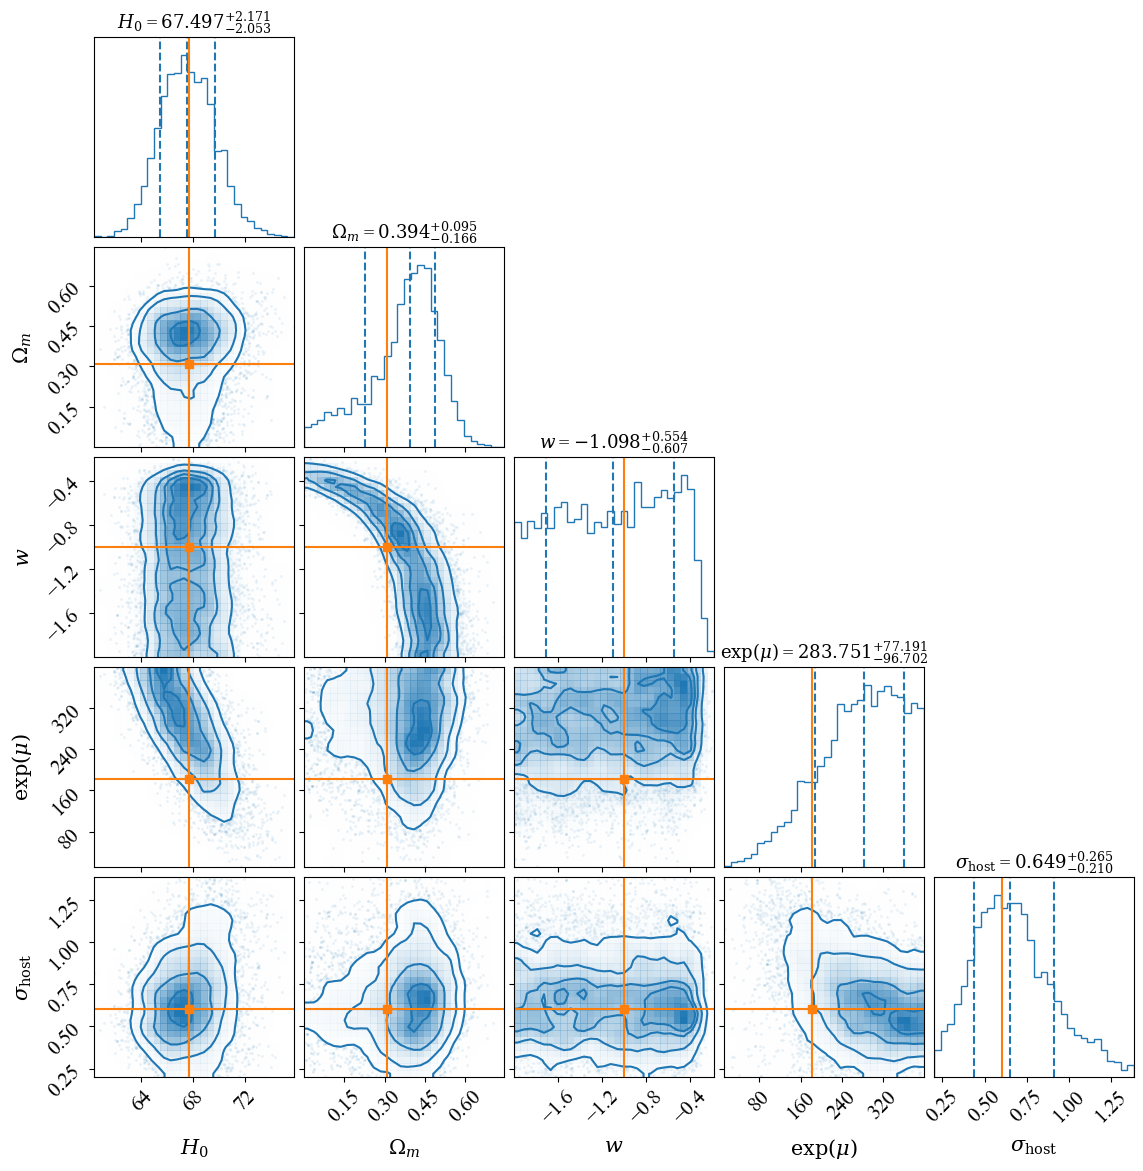

In [ ]:
posterior_ext = np.load('posterior/cluster_MCMC_DM_ext_all.npy')
param_names_ext = [r'$H_0$', r'$\Omega_m$', r'$w$', r'$\exp(\mu)$', r'$\sigma_{\rm host}$']
truth_ext=[HUBBLE, OMEGA_MATTER, W_LAMBDA, 182.937, 0.605]
mcmc_plot_results(posterior_ext, param_names_ext, truth_ext, savetitle="figures/MCMC_cluster_DM_ext_all", bins=30, target_prob=0.6827)

for DM_diff one

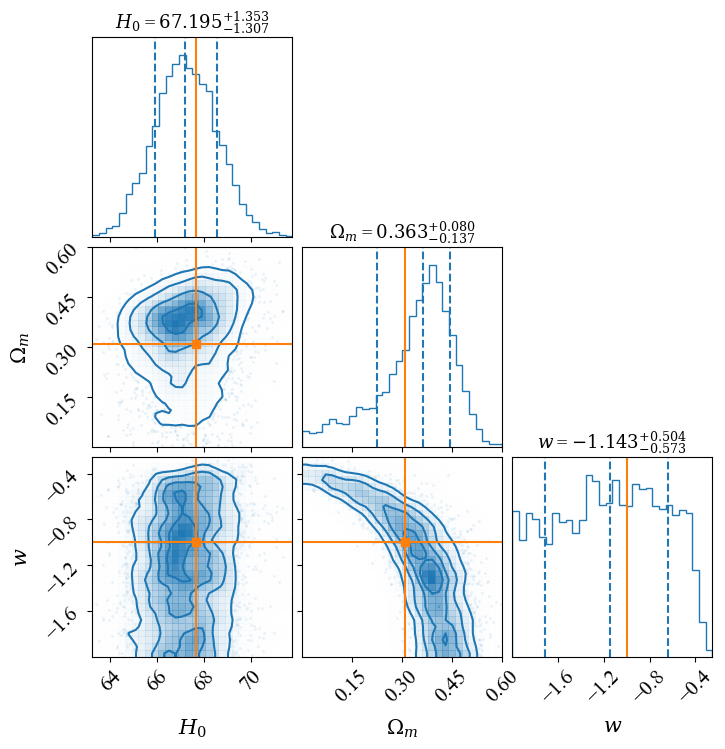

In [ ]:
posterior_diff = np.load('posterior/cluster_MCMC_DM_diff.npy')
param_names_diff = [r'$H_0$', r'$\Omega_m$', r'$w$']
truth_diff=[HUBBLE, OMEGA_MATTER, W_LAMBDA]
mcmc_plot_results(posterior_diff, param_names_diff, truth_diff, savetitle="figures/MCMC_cluster_DM_diff", bins=30, target_prob=0.6827)

## Comparison plots

In [3]:
lowz_diff_CE = np.load('./posterior/MCMC_DM_diff_02_CE.npy')
lowz_diff_LV = np.load('./posterior/MCMC_DM_diff_02_LVK.npy')
lowz_ext_CE = np.load('./posterior/MCMC_DM_ext_02_CE.npy')
lowz_ext_LV = np.load('./posterior/MCMC_DM_ext_02_LVK.npy')

highz_diff_CE = np.load('./posterior/cluster_MCMC_DM_diff.npy')
highz_ext_CE = np.load('./posterior/cluster_MCMC_DM_ext_all.npy')

**Low-z -- CE vs LV**

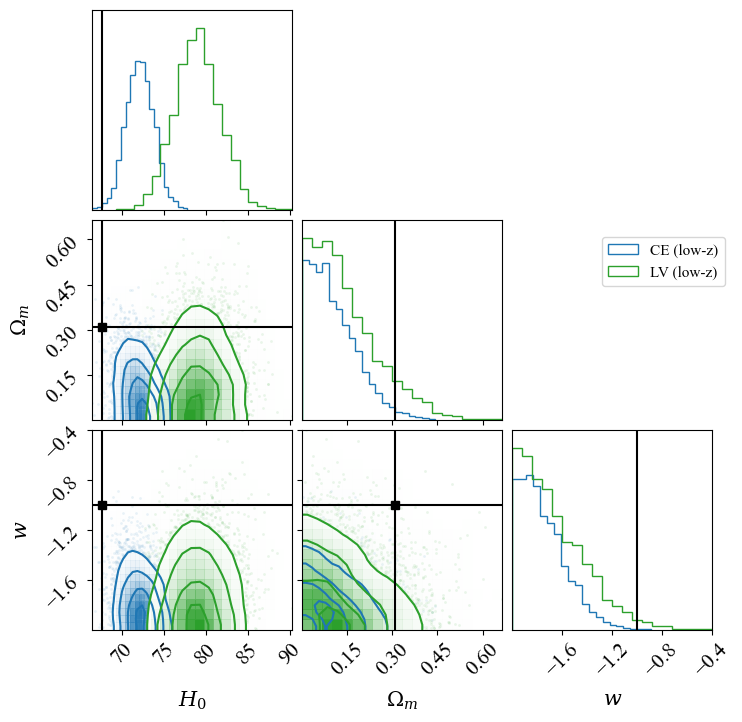

In [6]:
labels = [r"$H_0$", r"$\Omega_m$", r"$w$"]

fig = corner.corner(
    lowz_diff_CE, labels=labels, color="tab:blue", smooth=True, label_kwargs={"fontsize": 15},
)
corner.corner(
    lowz_diff_LV, fig=fig, truths=[HUBBLE, OMEGA_MATTER, W_LAMBDA], truth_color='black', color="tab:green", smooth=True
);

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=15)

plt.legend(['CE (low-z)', 'LV (low-z)'], loc='upper right', bbox_to_anchor=(0.1, 1., 1, 1), fontsize=11)
plt.show()

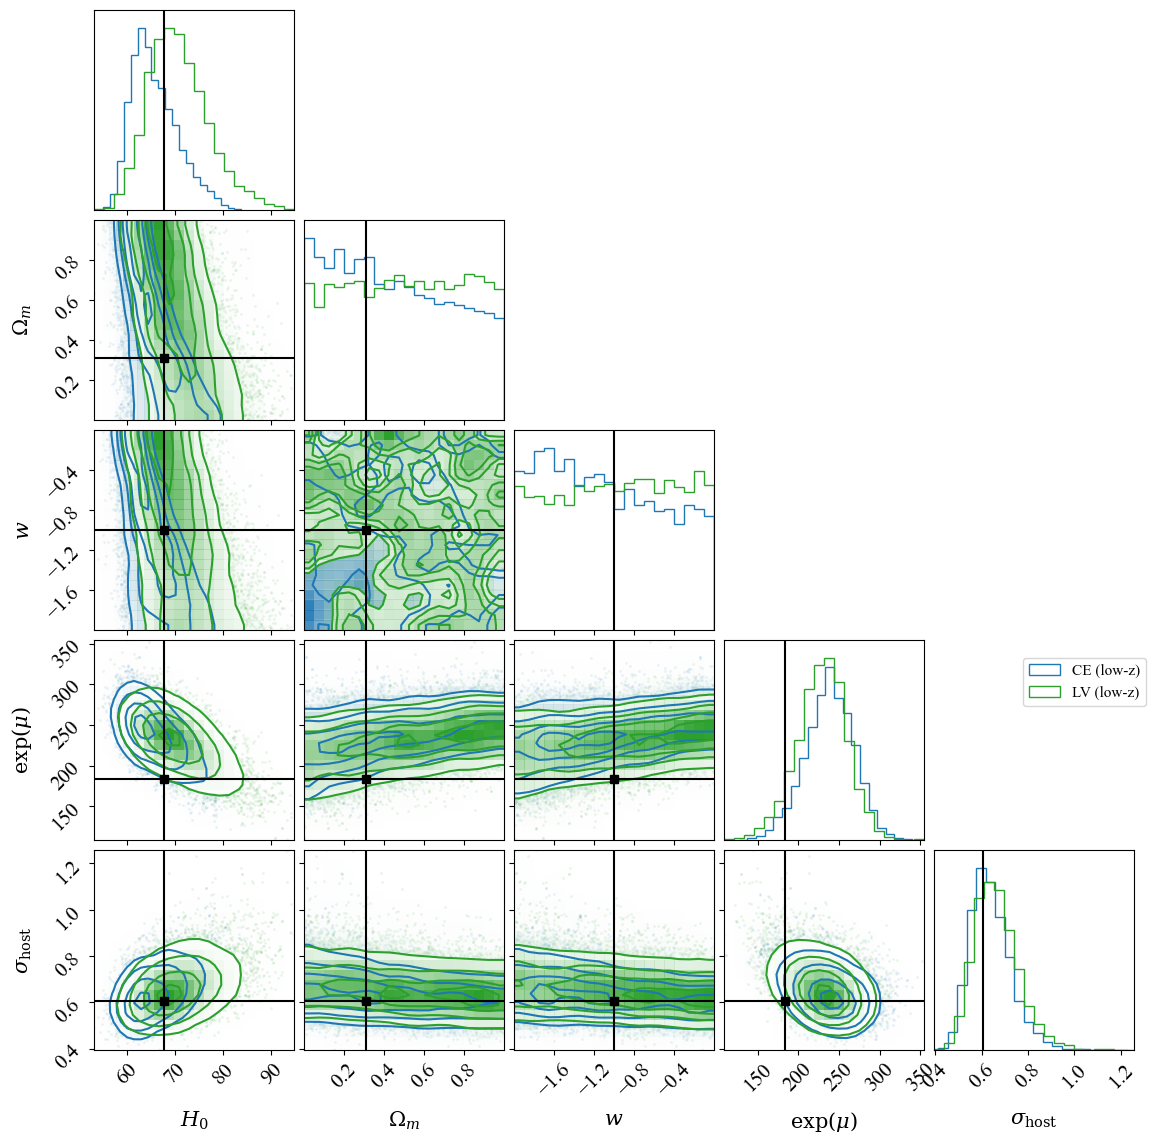

In [7]:
labels_all = [r"$H_0$", r"$\Omega_m$", r"$w$", r"$\exp(\mu)$", r"$\sigma_{\rm host}$"]

fig = corner.corner(
    lowz_ext_CE, labels=labels_all, color="tab:blue", smooth=True, label_kwargs={"fontsize": 15},
)
corner.corner(
    lowz_ext_LV, fig=fig, truths=[HUBBLE, OMEGA_MATTER, W_LAMBDA, EXP_MU, SIGMA_HOST], truth_color='black', color="tab:green", smooth=True
);

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=15)

plt.legend(['CE (low-z)', 'LV (low-z)'], loc='upper right', bbox_to_anchor=(0.1, 1., 1, 1), fontsize=11)
plt.show()

------------------------------------------

**CE -- high-z vs low-z**

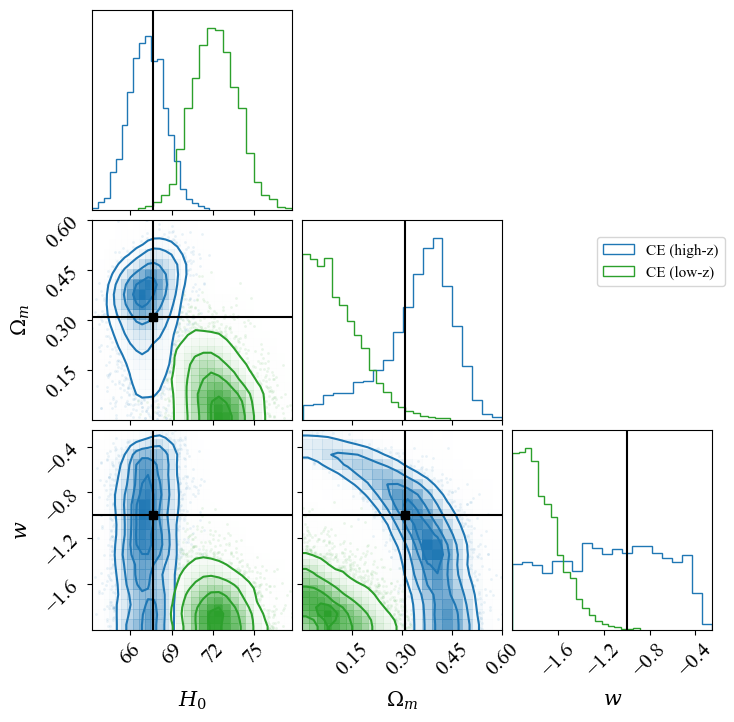

In [8]:
labels = [r"$H_0$", r"$\Omega_m$", r"$w$"]

fig = corner.corner(
    highz_diff_CE, labels=labels, color="tab:blue", smooth=True, label_kwargs={"fontsize": 15},
)
corner.corner(
    lowz_diff_CE, fig=fig, truths=[HUBBLE, OMEGA_MATTER, W_LAMBDA], truth_color='black', color="tab:green", smooth=True
);

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=15)

plt.legend(['CE (high-z)', 'CE (low-z)'], loc='upper right', bbox_to_anchor=(0.1, 1., 1, 1), fontsize=11)
plt.show()

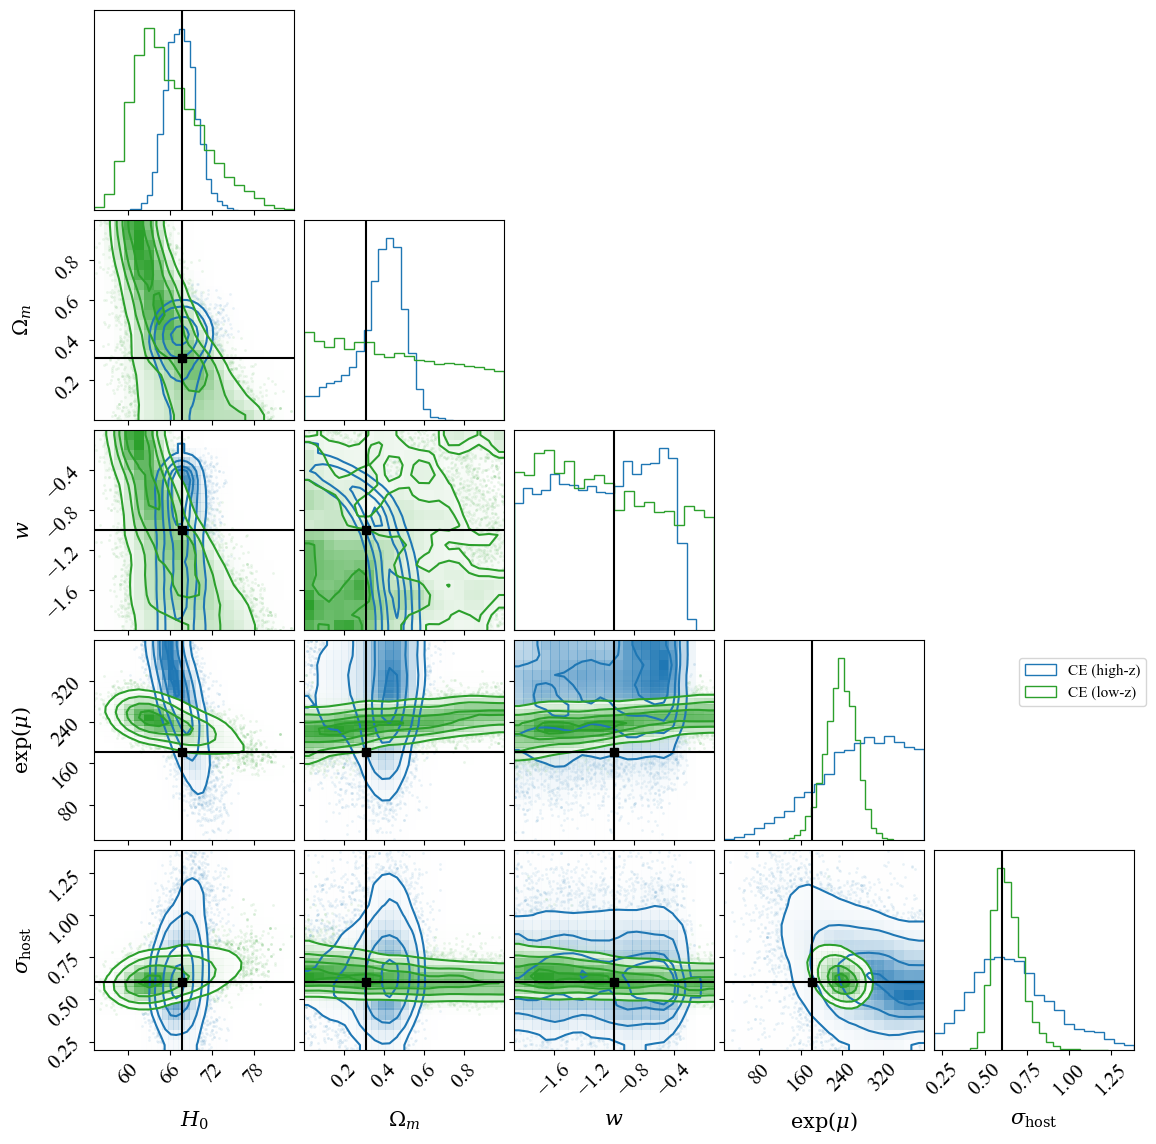

In [9]:
labels_all = [r"$H_0$", r"$\Omega_m$", r"$w$", r"$\exp(\mu)$", r"$\sigma_{\rm host}$"]

fig = corner.corner(
    highz_ext_CE, labels=labels_all, color="tab:blue", smooth=True, label_kwargs={"fontsize": 15},
)
corner.corner(
    lowz_ext_CE, fig=fig, truths=[HUBBLE, OMEGA_MATTER, W_LAMBDA, EXP_MU, SIGMA_HOST], truth_color='black', color="tab:green", smooth=True
);

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=15)

plt.legend(['CE (high-z)', 'CE (low-z)'], loc='upper right', bbox_to_anchor=(0.1, 1., 1, 1), fontsize=11)
plt.show()

data

In [ ]:
import pickle
import os
from pathlib import Path

DATA_FILE = './checkpoint/data.pkl'

if os.path.exists(DATA_FILE):
    # Load previously saved data
    print(f"Loading data from {DATA_FILE}...")
    with open(DATA_FILE, 'rb') as f:
        saved_data = pickle.load(f)
    
    # events redshifts
    z_centre = saved_data['z_centre']
    # DL data
    dL_obs_centre = saved_data['dL_obs_centre']
    sigma_dL = saved_data['sigma_dL']
    # DM_diff data
    DM_diff_obs = saved_data['DM_diff_obs']
    sigma_DM_diff = saved_data['sigma_DM_diff']
    # DM_ext data
    DM_ext_obs = saved_data['DM_ext_obs']
    sigma_DM_ext = saved_data['sigma_DM_ext']
    
    # Theoratical values (DM is the DM_diff)
    dL_centre = saved_data['dL_centre']
    DM_centre = saved_data['DM_centre']
    
    S = saved_data['S']
    Z_min = saved_data['Z_min']
    Z_max = saved_data['Z_max']
    REDSHIFT_METHOD = saved_data['REDSHIFT_METHOD']
    
    print(f"Successfully loaded {len(z_centre)} events from saved data.")
    
else:
    print(f"No data file {DATA_FILE}, please check path or generate data.")
    sys.exit()

Loading data from ./checkpoint/data_fast.pkl...
Successfully loaded 50 events from saved data.


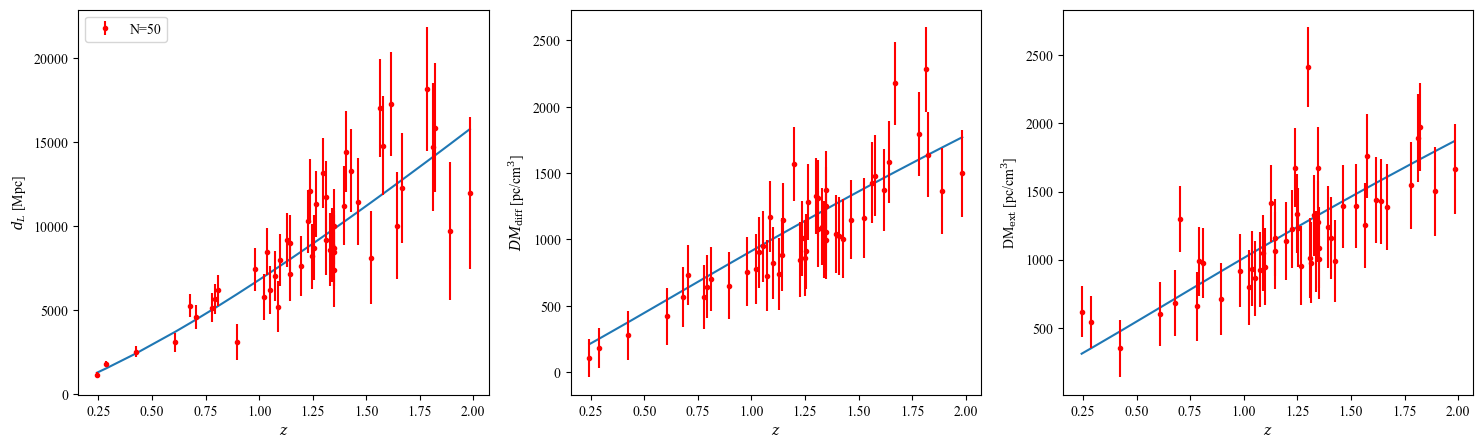

In [15]:
DATA_FIG="figures/events_DL_DM_redshift_distribution.png"

fig = plt.figure(figsize=(18, 5))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.plot(np.sort(z_centre), np.sort(dL_centre))
ax1.errorbar(z_centre, dL_obs_centre, yerr=sigma_dL, marker='o', ls='', ms=3, c='r', label=f'N={len(z_centre)}')
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left')

ax2.plot(np.sort(z_centre), np.sort(DM_centre))
ax2.errorbar(z_centre, DM_diff_obs, yerr=sigma_DM_diff, marker='o', ls='', ms=3, c='r')
ax2.set_ylabel(r'$DM_{\rm diff}$ [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')

ax3.plot(np.sort(z_centre), np.sort(DM_centre)+100)
ax3.errorbar(z_centre, DM_ext_obs, yerr=sigma_DM_ext, marker='o', ls='', ms=3, c='r')
ax3.set_ylabel(r'DM$_{\rm ext}$ [pc/cm$^3$]')
ax3.set_xlabel(r'$z$')

Path(DATA_FIG).parent.mkdir(parents=True, exist_ok=True)
plt.savefig(DATA_FIG)
# plt.tight_layout()